In [ ]:
#Simple linear regression is more than just drawing a line 
#it’s about understanding relationships, making predictions, and validating whether those predictions are statistically meaningful.

In [ ]:
# Step 1: Load and Visualize the Data

      TV  Radio  Newspaper  Sales
0  230.1   37.8       69.2   22.1
1   44.5   39.3       45.1   10.4
2   17.2   45.9       69.3   12.0
3  151.5   41.3       58.5   16.5
4  180.8   10.8       58.4   17.9
               TV       Radio   Newspaper       Sales
count  200.000000  200.000000  200.000000  200.000000
mean   147.042500   23.264000   30.554000   15.130500
std     85.854236   14.846809   21.778621    5.283892
min      0.700000    0.000000    0.300000    1.600000
25%     74.375000    9.975000   12.750000   11.000000
50%    149.750000   22.900000   25.750000   16.000000
75%    218.825000   36.525000   45.100000   19.050000
max    296.400000   49.600000  114.000000   27.000000


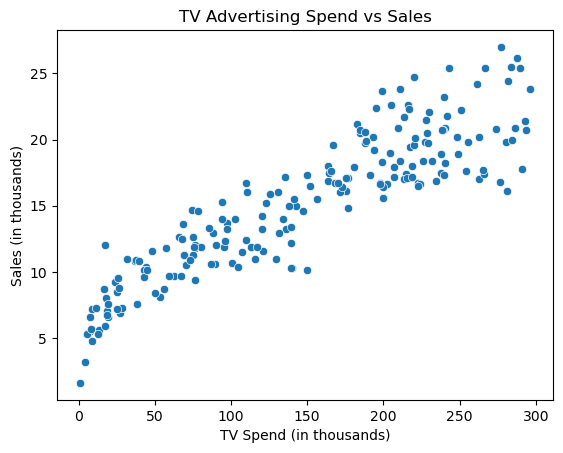

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the data
df = pd.read_csv("D:\\Phani\\etechguild\\syllabus\\demo\\lessons\\python\\ML-Linear Regression-8\\linear regression\\advertising.csv") 

# Quick look
print(df.head())
print(df.describe())

# Visualize TV vs Sales
sns.scatterplot(x='TV', y='Sales', data=df)
plt.title("TV Advertising Spend vs Sales")
plt.xlabel("TV Spend (in thousands)")
plt.ylabel("Sales (in thousands)")
plt.show()

# Linearity check by scatter plot?

In [ ]:
# Step 2: Split into Train/Test Sets

In [2]:
from sklearn.model_selection import train_test_split

X = df[['TV']]  # Predictor
y = df['Sales']  # Response

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [ ]:
# Step 3: Fit Model Using Statsmodels and Scikit-learn


In [ ]:
# Using statsmodels

In [3]:
import statsmodels.api as sm

X_train_sm = sm.add_constant(X_train)  # Add intercept
model_sm = sm.OLS(y_train, X_train_sm).fit()
print(model_sm.summary())


                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.813
Model:                            OLS   Adj. R-squared:                  0.812
Method:                 Least Squares   F-statistic:                     689.1
Date:                Wed, 27 Aug 2025   Prob (F-statistic):           1.71e-59
Time:                        18:48:40   Log-Likelihood:                -355.76
No. Observations:                 160   AIC:                             715.5
Df Residuals:                     158   BIC:                             721.7
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          7.0071      0.364     19.274      0.0

In [ ]:
# Using scikit-learn

In [4]:
from sklearn.linear_model import LinearRegression

model_sk = LinearRegression()
model_sk.fit(X_train, y_train)

print(f"Intercept: {model_sk.intercept_}")
print(f"Slope: {model_sk.coef_[0]}")


Intercept: 7.007108428241848
Slope: 0.0554829439314632


In [ ]:
# Step 4: Check Assumptions
# linearity (above via scatter plot)

In [ ]:
# Residuals Normally Distributed

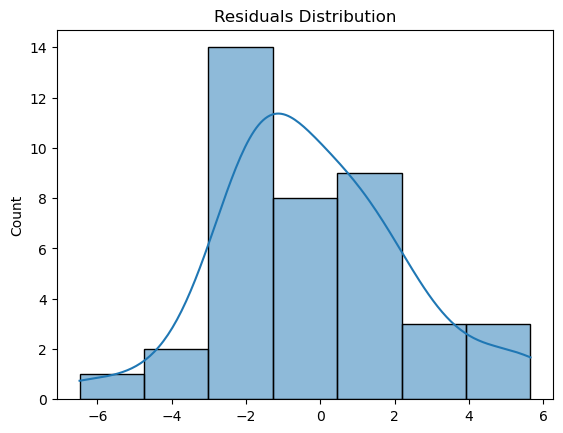

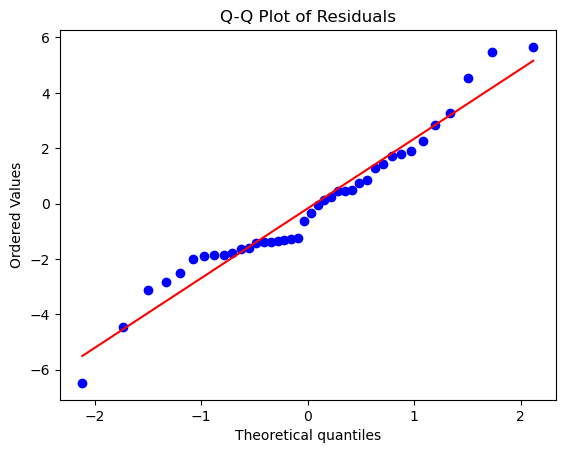

In [5]:
import scipy.stats as stats

# Residuals
X_test_sm = sm.add_constant(X_test)
y_pred_sm = model_sm.predict(X_test_sm)
residuals = y_test - y_pred_sm

# Histogram
sns.histplot(residuals, kde=True)
plt.title("Residuals Distribution")
plt.show()

# Q-Q Plot
stats.probplot(residuals, dist="norm", plot=plt)
plt.title("Q-Q Plot of Residuals")
plt.show()


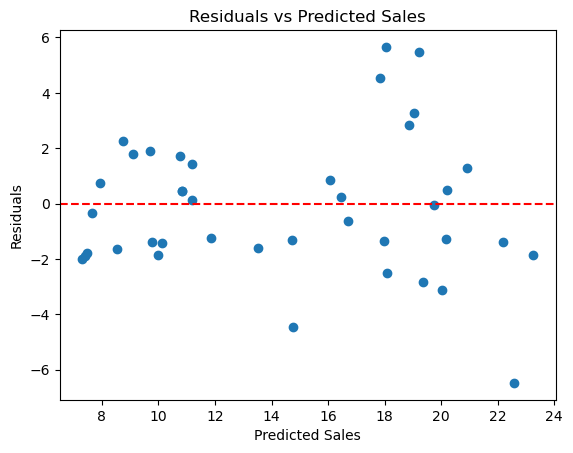

In [6]:
# Homoscedasticity (Constant Variance)
plt.scatter(y_pred_sm, residuals)
plt.axhline(0, color='red', linestyle='--')
plt.title("Residuals vs Predicted Sales")
plt.xlabel("Predicted Sales")
plt.ylabel("Residuals")
plt.show()


In [ ]:
#Step 5: Interpret Coefficients and p-values
 # above verification - Using statsmodels

In [ ]:
#Step 6: Evaluate Model (R² and Residuals)

In [ ]:
#R² Score

In [7]:
from sklearn.metrics import r2_score

y_pred_sk = model_sk.predict(X_test)
r2 = r2_score(y_test, y_pred_sk)
print(f"R² Score: {r2:.3f}")


R² Score: 0.803


In [ ]:
# Residual Plot  - refer above